In [1]:
rm(list = ls())

# check and install CRAN packages
cran_packages <- c("pheatmap", "ggplot2")

for (pkg in cran_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, dependencies = TRUE)
  }
}

lapply(cran_packages, library, character.only = TRUE)


[[1]]
[1] "pheatmap"  "repr"      "stats"     "graphics"  "grDevices" "utils"    
[7] "datasets"  "methods"   "base"     

[[2]]
 [1] "ggplot2"   "pheatmap"  "repr"      "stats"     "graphics"  "grDevices"
 [7] "utils"     "datasets"  "methods"   "base"

In [2]:
# load similarity matrix
data <- read.delim2("./lib/nucl_similarity_matrix.txt", sep = "\t", header = TRUE, row.names = 1, check.names = FALSE)
data <- round(apply(data, c(1,2), as.numeric), 0)
data[is.na(data)] <- 100  

gene_id <- data.frame(ID = colnames(data), stringsAsFactors = FALSE)
gene_id$Accession <- sapply(gene_id$ID, function(x) unlist(strsplit(x, "-"))[1])

accession_mapping <- c(
  "ATCT" = "Ct-1", "ATCol" = "Col-0", "ATAN" = "An-1",
  "ATERI" = "Eri-1", "ATLER" = "Ler-0", "ATKYO" = "Kyo-1",
  "ATSHA" = "Sha", "ATCVI" = "Cvi-1"
)
gene_id$Accession <- accession_mapping[gene_id$Accession]
gene_id$Class <- "hotspot"
gene_id$Class[grep("-5G", gene_id$ID)] <- "other"

In [3]:
# load annotation data
group <- read.delim2("./lib/ppr_gene_group.txt", header = TRUE, sep = "\t", check.names = TRUE)
gene_id$Group <- group$Group[match(gene_id$ID, group$PPR)]

# prepare annotation for pheatmap
annotation <- data.frame(
  Accession = gene_id$Accession,
  Class = gene_id$Class,
  Group = gene_id$Group,
  row.names = sub("\\..*$", "", gene_id$ID),
  stringsAsFactors = FALSE
)

rownames(data) <- sub("\\..*$", "", rownames(data))
colnames(data) <- sub("\\..*$", "", colnames(data))

# set annotation colors
ann_colors <- list(
  Class = c("hotspot" = "black", "other" = "lightgrey"),
  Accession = c(
    "An-1" = "#0000FF", "Col-0" = "#FFA500", "Ct-1" = "#FF0000",
    "Cvi-1" = "#800000", "Eri-1" = "#000080", "Kyo-1" = "#008000",
    "Ler-0" = "#800080", "Sha" = "#696969"
  ),
  Group = c("G1" = "#BB86D8", "G2" = "#62CA6F", "G3" = "orange")
)


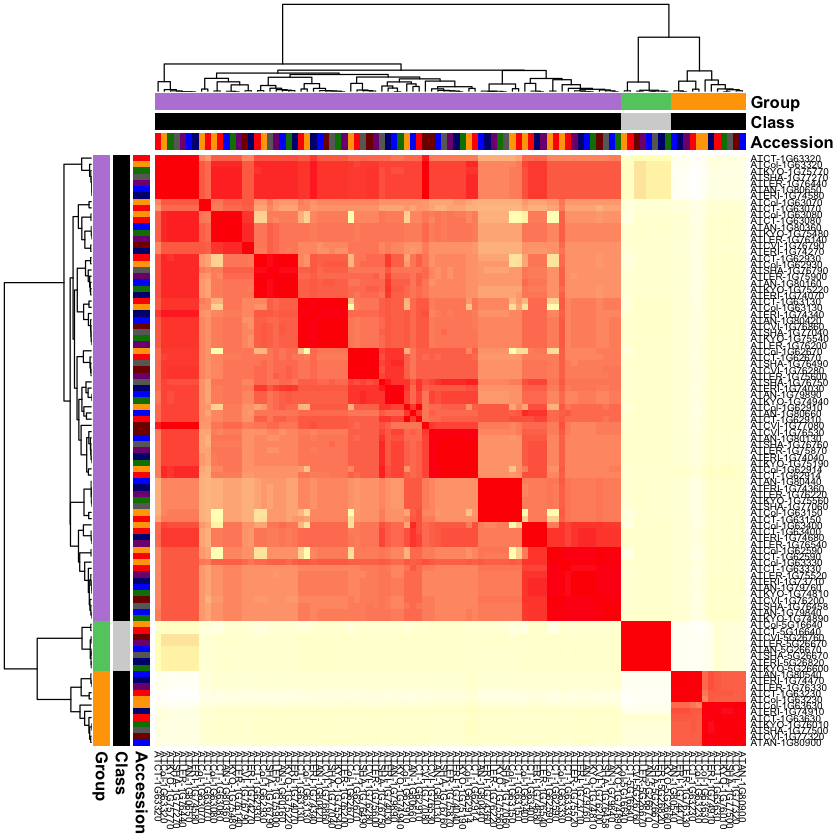

In [4]:
p <- pheatmap(
  data,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  color = colorRampPalette(colors = c("white", "#FFFFBF", "red"))(100),
  fontsize_row = 6,
  fontsize_col = 6,
  annotation_col = annotation,
  annotation_row = annotation,
  annotation_colors = ann_colors,
  legend = FALSE,
  annotation_legend = FALSE,
  border_color = NA
)

# save plot
ggsave(plot = p, filename = "ppr_nucl_seq_similarity.pdf", width = 10, height = 10)

In [5]:
order_ids <- p$tree_col$labels[p$tree_col$order]
write(order_ids, "./lib/pheatmap_gene_order.txt")